In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)

NumPy version: 1.24.4
Pandas version: 2.0.3
Matplotlib version: 3.7.1
Seaborn version: 0.12.2


In [30]:
red_wine = pd.read_csv("winequality-red.csv", sep=";")
white_wine = pd.read_csv("winequality-white.csv", sep=";")

In [31]:
red_wine["type"] = "red"
white_wine["type"] = "white"

In [32]:
wine = pd.concat([red_wine, white_wine], axis=0)

In [ ]:
#CHECK DATA SET INFO

In [41]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 710.6+ KB


In [33]:
print("Ukuran dataset:", wine.shape)
print("\nContoh data:\n", wine.describe())

Ukuran dataset: (6497, 13)

Contoh data:
        fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min   

In [34]:
print("\nStatistik Deskriptif:\n", wine.describe())


Statistik Deskriptif:
        fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.009000      

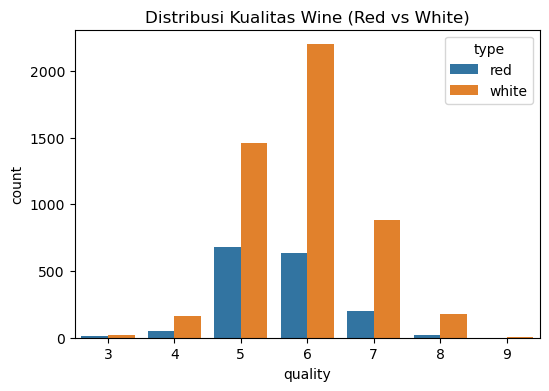

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(data=wine, x="quality", hue="type")
plt.title("Distribusi Kualitas Wine (Red vs White)")
plt.show()

In [36]:
#point 1 : Grafik ini menunjukkan distribusi kualitas wine berdasarkan skor 0–10. Warna biru untuk red wine, dan oranye untuk white wine.

In [37]:
#point 2 : Kita bisa lihat kebanyakan red wine berada di skor kualitas 5 dan 6, sementara white wine paling banyak di skor 6, lalu diikuti 5 dan 7.

In [38]:
#point 3 : Secara kualitas white wine mendapatkan skor lebih sedikit tinggi ketimbang red wine

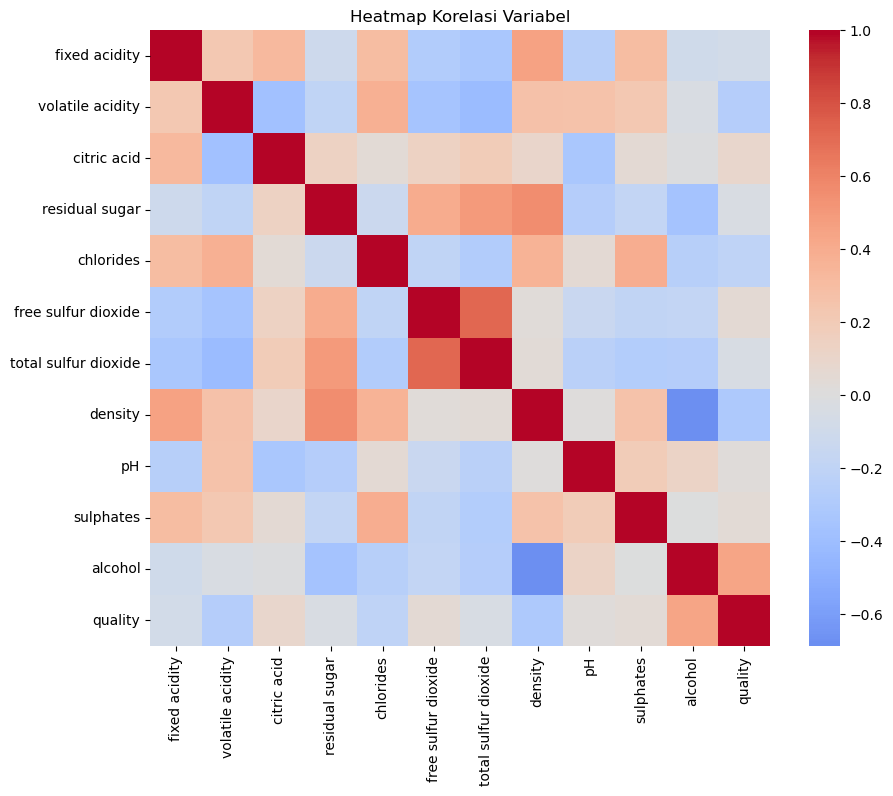

In [39]:
plt.figure(figsize=(10,8))
sns.heatmap(wine.select_dtypes(include="number").corr(),
            annot=False, cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Variabel")
plt.show()

In [14]:
# point 1 : Heatmap ini menggambarkan hubungan antarvariabel dalam dataset wine. Warna merah menunjukkan korelasi positif, sedangkan biru menunjukkan korelasi negatif

In [ ]:
# point 2 : Kadar alkohol memiliki korelasi positif cukup kuat dengan kualitas wine. Sebaliknya, volatile acidity berkorelasi negatif, artinya semakin tinggi volatile acidity, kualitas wine cenderung turun

In [ ]:
# point 3 : kita juga bisa lihat hubungan kuat antara free sulfur dioxide dan total sulfur dioxide, yang wajar korena keduanya saling terkait

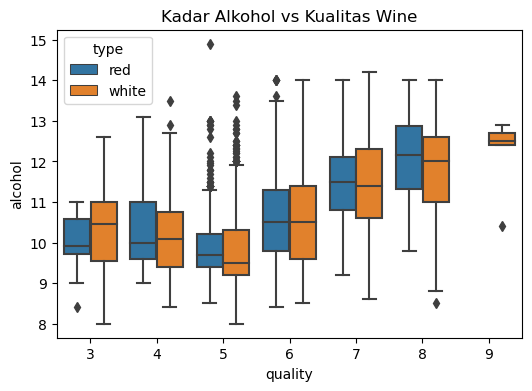

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(data=wine, x="quality", y="alcohol", hue="type")
plt.title("Kadar Alkohol vs Kualitas Wine")
plt.show()

In [ ]:
# point 1 : Boxplot ini menunjukan distribusi kadar alkohol berdasarkan kualitas wine

In [ ]:
# point 2 : wine dengan kualitas rendah dengan skore (3-5) memiliki kadar alkohol lebih rendah, sekitar 9-11%. Sementara wine dengan kualitas tinggi (7-9) mempunyai kadar alkohol lebih tinggi dari 11-14%.

In [ ]:
# point 3 : kadar alkohol adalah salah satu faktor utama yang mempengaruhi kualitas wine

In [ ]:
#KESIMPULANNYA : Secara menyeluruh, White wine cenderung lebih berkualitas ketimbang Red Wine, dan kadar alkohol menjadi variabel penentu kualitas wine

In [45]:
wine.groupby("type").mean(numeric_only=True)[["alcohol", "volatile acidity", "citric acid", "residual sugar"]]

,alcohol,volatile acidity,citric acid,residual sugar
type,,,,
red,10.422983,0.527821,0.270976,2.538806
white,10.514267,0.278241,0.334192,6.391415


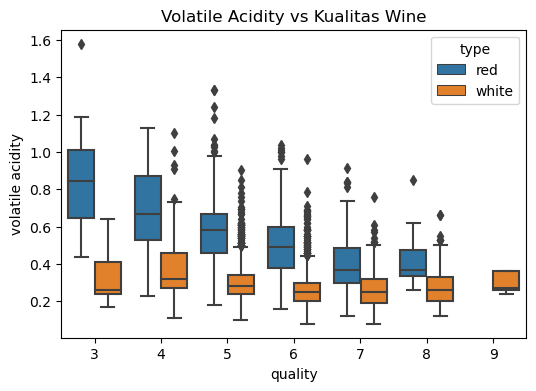

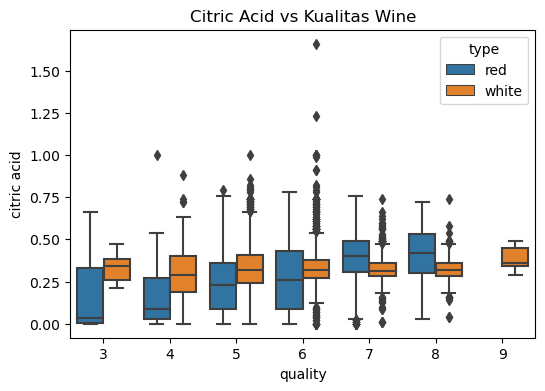

In [46]:
plt.figure(figsize=(6,4))
sns.boxplot(data=wine, x="quality", y="volatile acidity", hue="type")
plt.title("Volatile Acidity vs Kualitas Wine")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=wine, x="quality", y="citric acid", hue="type")
plt.title("Citric Acid vs Kualitas Wine")
plt.show()

In [ ]:
#Uji Statistik T-test red wine vs white wine

In [47]:
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(
    red_wine["alcohol"], 
    white_wine["alcohol"], 
    equal_var=False
)

print("T-test Alkohol (Red vs White)")
print("t-statistic:", t_stat, "p-value:", p_val)

T-test Alkohol (Red vs White)
t-statistic: -2.8590287839639132 p-value: 0.004277779864993421


In [ ]:
#PREDIKSI SEDERHANA

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Buat target kualitas (low=3-5, medium=6, high=7-9)
wine["quality_label"] = wine["quality"].apply(
    lambda q: "low" if q <= 5 else ("medium" if q == 6 else "high")
)

X = wine.drop(["quality", "quality_label", "type"], axis=1)
y = wine["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

# Feature importance
pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)


              precision    recall  f1-score   support

        high       0.71      0.62      0.66       365
         low       0.72      0.77      0.74       691
      medium       0.68      0.68      0.68       894

    accuracy                           0.70      1950
   macro avg       0.70      0.69      0.70      1950
weighted avg       0.70      0.70      0.70      1950



alcohol                 0.137357
volatile acidity        0.106860
density                 0.102535
total sulfur dioxide    0.088333
chlorides               0.086455
free sulfur dioxide     0.083441
residual sugar          0.083402
sulphates               0.082161
pH                      0.081408
citric acid             0.076849
fixed acidity           0.071199
dtype: float64